In [2]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
# Load MCS track file (HPC)
# mcs_file_obs = "//pscratch/sd/f/feng045/waccem/mcs_global/stats/mcs_tracks_final_extc_20200101.0000_20210101.0000.nc"
# ds_mcs_obs = xr.open_dataset(mcs_file_obs)

# mcs_file_icon = "/global/cfs/cdirs/m4581/gsharing/hackathon/tracking/mcs/icon_d3hp003/stats/mcs_tracks_final_20200102.0000_20201231.2330.nc"
# ds_mcs_icon = xr.open_dataset(mcs_file_icon)

# mcs_file_scream = "/global/cfs/cdirs/m4581/gsharing/hackathon/tracking/mcs/scream/stats/mcs_tracks_final_20190801.0000_20200901.0000.nc"
# ds_mcs_scream = xr.open_dataset(mcs_file_scream)

# mcs_file_um = "/global/cfs/cdirs/m4581/gsharing/hackathon/tracking/mcs/um_glm_n2560_RAL3p3/stats/mcs_tracks_final_20200201.0000_20210301.0000.nc"
# ds_mcs_um = xr.open_dataset(mcs_file_um)

# mcs_file_ifs = "/pscratch/sd/p/paccini/IFS_mcs_hackathon/ifs_tco3999_rcbmf/stats/mcs_tracks_final_20200101.0000_20210228.2330.nc"
# ds_mcs_ifs = xr.open_dataset(mcs_file_ifs)

In [3]:
# Load MCS track file (local)
mcs_file_obs = "/Users/pacc275/local_documents/hackathon/mcs_tracks_final_extc_20200101.0000_20210101.0000.nc"
ds_mcs_obs = xr.open_dataset(mcs_file_obs)

mcs_file_icon = "/Users/pacc275/local_documents/hackathon/mcs_final_icon_20200102.0000_20201231.2330.nc"
ds_mcs_icon = xr.open_dataset(mcs_file_icon)

mcs_file_scream = "/Users/pacc275/local_documents/hackathon/mcs_tracks_final_20190801.0000_20200901.0000.nc"
ds_mcs_scream = xr.open_dataset(mcs_file_scream)

mcs_file_um = "/Users/pacc275/local_documents/hackathon/mcs_tracks_final_um_20200201.0000_20210301.0000.nc"
ds_mcs_um = xr.open_dataset(mcs_file_um)

In [3]:
!ls '/global/cfs/cdirs/m4581/gsharing/hackathon/tracking/mcs/um_glm_n2560_RAL3p3/stats/mcs_tracks_final_20200201.0000_20210301.0000.nc'

/global/cfs/cdirs/m4581/gsharing/hackathon/tracking/mcs/um_glm_n2560_RAL3p3/stats/mcs_tracks_final_20200201.0000_20210301.0000.nc


In [42]:
ds_mcs_obs.track_duration.to_dataframe().reset_index().describe()

,tracks,track_duration
count,32138.000000,32138.000000
mean,16068.500000,19.309073
std,9277.585812,11.708623
min,0.000000,5.000000
25%,8034.250000,12.000000
50%,16068.500000,17.000000
75%,24102.750000,24.000000
max,32137.000000,198.000000


In [21]:
def MCS_filter(ds_mcs,ilat = -30, elat = 30,filter_split=True,min_ini_nonmcs=3,nomerging=False,nopeak=False,):
    #i) MCS do not start with a split 
    if filter_split:
        mask = np.isnan(ds_mcs.start_split_cloudnumber)
        ds_nosplit = ds_mcs.sel(tracks=mask)
        del(ds_mcs)
        ds_mcs = ds_nosplit.copy()
    # Also apply spatial filtering (tropical tracks like your script)
    initial_lats = ds_mcs.meanlat.isel(times=0).values
    initial_lons = ds_mcs.meanlon.isel(times=0).values
    
    # ii) Tropical filter (-30 to 30 latitude)
    mask_tropical = (initial_lats >= ilat) & (initial_lats <= elat)
    # mask_tropical = mask_tropical.drop_vars('times', errors='ignore') # Avoid coordinate conflicts

    # initial_lats = ds_mcs.meanlat.isel(times=0)
    # mask_tropical = (initial_lats >= ilat) & (initial_lats <= elat)
    # mask_tropical = mask_tropical.drop_vars('times', errors='ignore') # Avoid coordinate conflicts

    
    mask_lf = ds_mcs.pf_landfrac.sum('times') < 0.1

    # iv) No merging 
    mask_start_status = (ds_mcs.start_status == 1) | (ds_mcs.start_status == 2)
    mask_end_status = (ds_mcs.end_status == 0) | (ds_mcs.end_status == 3)

    # v)  MCSs with first three time steps are non MCSs
    mask_initial_non_mcs = ds_mcs.mcs_status.isel(times=slice(0, min_ini_nonmcs)).sum(dim='times') == 0
    mask_initial_non_mcs = mask_initial_non_mcs.drop_vars('times', errors='ignore')

    # vi) stable MCSs & total rain peak within MCS status 
    # Sum the mcs_status (0s and 1s) over time. This sum must equal the total mcs_duration.
    mcs_hours_sum = ds_mcs.mcs_status.sum(dim='times')
    mask_continuous_mcs = (mcs_hours_sum == ds_mcs.mcs_duration)
    mask_continuous_mcs = mask_continuous_mcs.drop_vars('times', errors='ignore')


    # Total rainfall must peak during an MCS status (mcs_status == 1)
    peak_rain_time_idx = ds_mcs.total_rain.argmax(dim='times')
    status_at_peak_rain = ds_mcs.mcs_status.isel(times=peak_rain_time_idx)
    # The mask is true where that status is 1.
    mask_peak_rain = (status_at_peak_rain == 1)
    mask_peak_rain = mask_peak_rain.drop_vars('times', errors='ignore')

    # final extracted MCSs
    if nomerging:
        final_mcs = ((mask_tropical) & (mask_lf) &  \
                                  (mask_peak_rain) & (mask_initial_non_mcs) & (mask_continuous_mcs))
    elif nopeak:
        final_mcs = ((mask_tropical) & (mask_lf) & (mask_start_status) & (mask_end_status) & \
                                 (mask_initial_non_mcs) )
    else:
        final_mcs = ((mask_tropical) & (mask_lf) & (mask_start_status) & (mask_end_status) & \
                                  (mask_peak_rain) & (mask_initial_non_mcs) & (mask_continuous_mcs))
        

    # cumulative_mask = xr.full_like(ds_mcs.tracks, fill_value=True, dtype=bool)

    # for name, mask in filters_to_apply.items():
    #     cumulative_mask &= mask
        
    ## Apply final combined mask 
    final_ds = ds_mcs.where(final_mcs, drop=True)

    # Create a summary DataFrame
    tracks_of_interest = pd.DataFrame({
        'track_id':  final_ds.tracks.values,
        'duration_hours': final_ds.track_duration.values,
        'time_to_max_area': final_ds.area.argmax(dim="times").values.astype(int),
        'initial_lat': final_ds.meanlat.isel(times=0).values,
        'initial_lon': final_ds.meanlon.isel(times=0).values,
        'lifetime_maxmax_pf_area': final_ds.pf_area.max('times').max('nmaxpf').values,
        # 'lifetime_maxmean_pf_area': tropical_lifetime_maxmean_pf_area,
        # 'lifetime_maxmedian_pf_area': tropical_lifetime_maxmedian_pf_area,
        'mean_area': final_ds.area.mean('times').values,
        'median_area': final_ds.area.median('times').values,
        'total_area': final_ds.area.sum('times').values,
        'max_total_rain': final_ds.total_rain.max('times').values,
        'mean_total_rain': final_ds.total_rain.mean('times').values,
        'median_total_rain': final_ds.total_rain.median('times').values,
        'total_total_rain': final_ds.total_rain.sum('times').values,
        'mean_pf_rain': final_ds.pf_rainrate.mean(['times','nmaxpf']).values,
        'median_pf_rain': final_ds.pf_rainrate.median(['times','nmaxpf']).values,
        'total_pf_rain': final_ds.pf_rainrate.sum(['times','nmaxpf']).values,
        'mean_landfrac': final_ds.pf_landfrac.mean('times').values,
        'total_landfrac': final_ds.pf_landfrac.sum('times').values,
        'start_time': final_ds.start_basetime.values,
        'mean_eccentricity': final_ds.pf_eccentricity.mean(['times','nmaxpf']).values,
        'mean_aspectratio': final_ds.pf_aspectratio.mean(['times','nmaxpf']).values,
        'mean_majoraxis': final_ds.pf_majoraxis.mean(['times','nmaxpf']).values,
        'mean_minoraxis': final_ds.pf_minoraxis.mean(['times','nmaxpf']).values,
        'mean_orientation': final_ds.pf_orientation.mean(['times','nmaxpf']).values,
        'median_eccentricity': final_ds.pf_eccentricity.median(['times','nmaxpf']).values,
        'median_aspectratio': final_ds.pf_aspectratio.median(['times','nmaxpf']).values,
        'median_majoraxis': final_ds.pf_majoraxis.median(['times','nmaxpf']).values,
        'median_minoraxis': final_ds.pf_minoraxis.median(['times','nmaxpf']).values,
        'median_orientation': final_ds.pf_orientation.median(['times','nmaxpf']).values
        
    })

    return(tracks_of_interest)

In [17]:
def analyze_filter_impact(ds_mcs, ilat=-30, elat=30, min_ini_nonmcs=3):
    """
    Applies a series of vectorized filters, analyzes the impact of each filter,
    and returns the final filtered data along with the impact analysis.
    """
    # --- 1. Create a boolean mask for each individual condition ---

    # Baseline conditions
    mask_nosplit = ds_mcs.start_split_cloudnumber.isnull()
    initial_lats = ds_mcs.meanlat.isel(times=0)
    mask_tropical = (initial_lats >= ilat) & (initial_lats <= elat)
    mask_tropical = mask_tropical.drop_vars('times', errors='ignore') # Avoid coordinate conflicts
    mask_lf = ds_mcs.pf_landfrac.sum('times') < 0.1

    # Additional filtering conditions
    # No merging
    mask_start_status = (ds_mcs.start_status == 1) | (ds_mcs.start_status == 2)
    mask_end_status = (ds_mcs.end_status == 0) | (ds_mcs.end_status == 3)
    mask_merging = mask_start_status & mask_end_status

    # Initial Non-MCS Status
    mask_initial_non_mcs = (ds_mcs.mcs_status.isel(times=slice(0, min_ini_nonmcs)).sum(dim='times') == 0)
    mask_initial_non_mcs = mask_initial_non_mcs.drop_vars('times', errors='ignore')

    # Stable & Rain Peak in MCS 
    mcs_hours_sum = ds_mcs.mcs_status.sum(dim='times')
    mask_continuous_mcs = (mcs_hours_sum == ds_mcs.mcs_duration)
    mask_continuous_mcs = mask_continuous_mcs.drop_vars('times', errors='ignore')

    peak_rain_time_idx = ds_mcs.total_rain.argmax(dim='times')
    status_at_peak_rain = ds_mcs.mcs_status.isel(times=peak_rain_time_idx)
    mask_peak_rain = (status_at_peak_rain == 1)
    mask_peak_rain = mask_peak_rain.drop_vars('times', errors='ignore')

    mask_stability_and_peak = mask_continuous_mcs & mask_peak_rain

    # --- 2. Sequentially apply filters to analyze their impact ---
    impact_stats = []
    n_initial = ds_mcs.tracks.size

    impact_stats.append({'Filter Stage': 'Initial Total', 'Tracks Remaining': n_initial, 'Tracks Dropped': 0})

    filters_to_apply = {
        'Baseline (No Split & Tropics & LF <0.1)': mask_nosplit & mask_tropical & mask_lf,
        '+ No Merging': mask_merging,
        '+ Initial Non-MCS Status': mask_initial_non_mcs,
        '+ Stable & Rain Peak in MCS': mask_stability_and_peak
    }

    filters_to_apply_unique = {
        'Baseline (No Split & Tropics & LF <0.1)': mask_nosplit & mask_tropical & mask_lf,
        'Baseline + No Merging': mask_nosplit & mask_tropical & mask_lf & mask_merging,
        'Baseline + Initial Non-MCS Status':  mask_nosplit & mask_tropical & mask_lf & mask_initial_non_mcs,
        'Baseline + Rain Peak in MCS':  mask_nosplit & mask_tropical & mask_lf & mask_stability_and_peak,
        'Baseline + No Merging & Initial Non-MCS Status':mask_nosplit & mask_tropical & mask_lf & mask_merging & mask_initial_non_mcs,
        'Baseline + No Merging & Rain Peak in MCS':mask_nosplit & mask_tropical & mask_lf & mask_merging & mask_stability_and_peak,
        'Baseline + Initial Non-MCS Status & Rain Peak in MCS':mask_nosplit & mask_tropical & mask_lf & mask_initial_non_mcs & mask_stability_and_peak
    }

    cumulative_mask = xr.full_like(ds_mcs.tracks, fill_value=True, dtype=bool)
    previous_count = n_initial

    for name, mask in filters_to_apply.items():
        cumulative_mask &= mask
        current_count = int(cumulative_mask.sum().item())
        dropped = previous_count - current_count
        impact_stats.append({'Filter Stage': name, 'Tracks Remaining': current_count, 'Tracks Dropped': dropped})
        previous_count = current_count

    filter_impact_df = pd.DataFrame(impact_stats).set_index('Filter Stage')

    unique_impact_stats = []
    n_initial = ds_mcs.tracks.size

    unique_impact_stats.append({'Filter Stage': 'Initial Total', 'Unique Tracks': n_initial, })

    for name, mask in filters_to_apply_unique.items():
        current_count = len(mask[mask==True])
        unique_impact_stats.append({'Filter Stage': name, 'Unique Tracks': current_count})

    filter_unique_impact_df = pd.DataFrame(unique_impact_stats).set_index('Filter Stage')

    
    return filter_impact_df,filter_unique_impact_df 

In [18]:
c_impact_obs, i_impact_obs = analyze_filter_impact(ds_mcs_obs)
print("--- Filter Impact Analysis ---")
print(c_impact_obs)

print("\n--- Final Filtered Tracks ---")
print(i_impact_obs)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       32138               0
Baseline (No Split & Tropics & LF <0.1)              6435           25703
+ No Merging                                         4200            2235
+ Initial Non-MCS Status                             3693             507
+ Stable & Rain Peak in MCS                          2825             868

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               32138
Baseline (No Split & Tropics & LF <0.1)                      6435
Baseline + No Merging                                        4200
Baseline + Initial Non-MCS Status                            5449
Baseline + Rain Peak in 

In [19]:
c_impact_obs1, i_impact_obs1 = analyze_filter_impact(ds_mcs_obs,min_ini_nonmcs=1)
print("--- Filter Impact Analysis ---")
print(c_impact_obs1)

print("\n--- Final Filtered Tracks ---")
print(i_impact_obs1)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       32138               0
Baseline (No Split & Tropics & LF <0.1)              6435           25703
+ No Merging                                         4200            2235
+ Initial Non-MCS Status                             4134              66
+ Stable & Rain Peak in MCS                          3201             933

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               32138
Baseline (No Split & Tropics & LF <0.1)                      6435
Baseline + No Merging                                        4200
Baseline + Initial Non-MCS Status                            6227
Baseline + Rain Peak in 

In [20]:
c_impact_icon, i_impact_icon = analyze_filter_impact(ds_mcs_icon)
print("--- Filter Impact Analysis ---")
print(c_impact_icon)

print("\n--- Final Filtered Tracks ---")
print(i_impact_icon)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       43577               0
Baseline (No Split & Tropics & LF <0.1)              4681           38896
+ No Merging                                         1991            2690
+ Initial Non-MCS Status                             1231             760
+ Stable & Rain Peak in MCS                           802             429

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               43577
Baseline (No Split & Tropics & LF <0.1)                      4681
Baseline + No Merging                                        1991
Baseline + Initial Non-MCS Status                            2564
Baseline + Rain Peak in 

In [21]:
c_impact_scream, i_impact_scream = analyze_filter_impact(ds_mcs_scream)
print("--- Filter Impact Analysis ---")
print(c_impact_scream)

print("\n--- Final Filtered Tracks ---")
print(i_impact_scream)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       56487               0
Baseline (No Split & Tropics & LF <0.1)              8128           48359
+ No Merging                                         4664            3464
+ Initial Non-MCS Status                             3336            1328
+ Stable & Rain Peak in MCS                          1936            1400

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               56487
Baseline (No Split & Tropics & LF <0.1)                      8128
Baseline + No Merging                                        4664
Baseline + Initial Non-MCS Status                            5518
Baseline + Rain Peak in 

In [22]:
c_impact_scream1, i_impact_scream1 = analyze_filter_impact(ds_mcs_scream,min_ini_nonmcs=1)
print("--- Filter Impact Analysis ---")
print(c_impact_scream1)

print("\n--- Final Filtered Tracks ---")
print(i_impact_scream1)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       56487               0
Baseline (No Split & Tropics & LF <0.1)              8128           48359
+ No Merging                                         4664            3464
+ Initial Non-MCS Status                             4491             173
+ Stable & Rain Peak in MCS                          2748            1743

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               56487
Baseline (No Split & Tropics & LF <0.1)                      8128
Baseline + No Merging                                        4664
Baseline + Initial Non-MCS Status                            7625
Baseline + Rain Peak in 

In [23]:
c_impact_um, i_impact_um = analyze_filter_impact(ds_mcs_um)
print("--- Filter Impact Analysis ---")
print(c_impact_um)

print("\n--- Final Filtered Tracks ---")
print(i_impact_um)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       39340               0
Baseline (No Split & Tropics & LF <0.1)              8802           30538
+ No Merging                                         4992            3810
+ Initial Non-MCS Status                             4334             658
+ Stable & Rain Peak in MCS                          2610            1724

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               39340
Baseline (No Split & Tropics & LF <0.1)                      8802
Baseline + No Merging                                        4992
Baseline + Initial Non-MCS Status                            7355
Baseline + Rain Peak in 

In [24]:
c_impact_ifs, i_impact_ifs = analyze_filter_impact(ds_mcs_ifs)
print("--- Filter Impact Analysis ---")
print(c_impact_ifs)

print("\n--- Final Filtered Tracks ---")
print(i_impact_ifs)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       32327               0
Baseline (No Split & Tropics & LF <0.1)              3132           29195
+ No Merging                                         1473            1659
+ Initial Non-MCS Status                             1203             270
+ Stable & Rain Peak in MCS                           847             356

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               32327
Baseline (No Split & Tropics & LF <0.1)                      3132
Baseline + No Merging                                        1473
Baseline + Initial Non-MCS Status                            2344
Baseline + Rain Peak in 

In [25]:
np.unique(ds_mcs_ifs.base_time)

array(['2020-01-01T01:00:00.000000000', '2020-01-01T02:00:00.000000000',
       '2020-01-01T03:00:00.000000000', ...,
       '2021-02-28T22:00:00.000000000', '2021-02-28T23:00:00.000000000',
                                 'NaT'],
      shape=(10200,), dtype='datetime64[ns]')

In [26]:
np.unique(ds_mcs_um.base_time)

array(['2020-02-01T00:00:00.000000000', '2020-02-01T01:00:00.000000000',
       '2020-02-01T02:00:00.000000000', ...,
       '2021-02-28T22:00:00.000000000', '2021-02-28T23:00:00.000000000',
                                 'NaT'],
      shape=(9457,), dtype='datetime64[ns]')

In [27]:
np.unique(ds_mcs_icon.base_time)

array(['2020-01-02T00:00:00.000000000', '2020-01-02T01:00:00.000000000',
       '2020-01-02T02:00:00.000000000', ...,
       '2020-12-31T22:00:00.000000000', '2020-12-31T23:00:00.000000000',
                                 'NaT'],
      shape=(8761,), dtype='datetime64[ns]')

In [44]:
df_trop_scream.duration_hours.describe()

count    1936.000000
mean       18.955062
std         9.641134
min         7.000000
25%        13.000000
50%        17.000000
75%        22.000000
max       174.000000
Name: duration_hours, dtype: float64

In [12]:
df_trop_obs = MCS_filter(ds_mcs_obs)

In [13]:
df_trop_obs.track_id.unique()

array([   48,    53,    56, ..., 32123, 32128, 32131], shape=(2825,))

In [14]:
df_trop_icon = MCS_filter(ds_mcs_icon)
df_trop_scream = MCS_filter(ds_mcs_scream)
df_trop_um = MCS_filter(ds_mcs_um)
# df_trop_ifs = MCS_filter(ds_mcs_ifs)

In [15]:
!pwd

/Users/pacc275/local_documents/local_repositories/gsrm_mcs_environments/analysis


In [19]:
df_trop_obs2 = MCS_filter(ds_mcs_obs,min_ini_nonmcs=2)
df_trop_icon2 = MCS_filter(ds_mcs_icon,min_ini_nonmcs=2)
df_trop_scream2 = MCS_filter(ds_mcs_scream,min_ini_nonmcs=2)
df_trop_um2 = MCS_filter(ds_mcs_um,min_ini_nonmcs=2)

In [22]:
## Filter with no merging 
df_trop_obs_nm = MCS_filter(ds_mcs_obs,nomerging=True)
df_trop_icon_nm = MCS_filter(ds_mcs_icon,nomerging=True)
df_trop_scream_nm = MCS_filter(ds_mcs_scream,nomerging=True)
df_trop_um_nm = MCS_filter(ds_mcs_um,nomerging=True)

In [23]:
df_trop_obs_nm.track_id.unique()

array([   27,    29,    48, ..., 32123, 32128, 32131], shape=(4246,))

In [24]:
## Filter with no peak MCS 
df_trop_obs_np = MCS_filter(ds_mcs_obs,nopeak=True)
df_trop_icon_np = MCS_filter(ds_mcs_icon,nopeak=True)
df_trop_scream_np = MCS_filter(ds_mcs_scream,nopeak=True)
df_trop_um_np = MCS_filter(ds_mcs_um,nopeak=True)

In [25]:
df_trop_obs_np.track_id.unique()

array([   48,    53,    56, ..., 32123, 32128, 32131], shape=(3693,))

In [39]:
# HPC
# outdir = '/pscratch/sd/p/paccini/temp/hackathon/filtered_mcs_track_ids

#local 
outdir = '/Users/pacc275/local_documents/hackathon/filtered_mcs_track_ids/'

In [30]:
!mkdir /Users/pacc275/local_documents/hackathon/filtered_mcs_track_ids

In [40]:
df_trop_obs.to_pickle(outdir+'df_trop_obs.pkl')
df_trop_icon.to_pickle(outdir+'df_trop_icon.pkl')
df_trop_scream.to_pickle(outdir+'df_trop_scream.pkl')
df_trop_um.to_pickle(outdir+'df_trop_um.pkl')

df_trop_obs2.to_pickle(outdir+'df_trop_obs_min2.pkl')
df_trop_icon2.to_pickle(outdir+'df_trop_icon_min2.pkl')
df_trop_scream2.to_pickle(outdir+'df_trop_scream_min2.pkl')
df_trop_um2.to_pickle(outdir+'df_trop_um_min2.pkl') 

In [20]:

# df_trop_ifs.to_pickle(outdir+'df_trop_ifs.pkl')


In [41]:
df_trop_obs_nm.to_pickle(outdir+'df_trop_obs_nm.pkl')
df_trop_icon_nm.to_pickle(outdir+'df_trop_icon_nm.pkl')
df_trop_scream_nm.to_pickle(outdir+'df_trop_scream_nm.pkl')
df_trop_um_nm.to_pickle(outdir+'df_trop_um_nm.pkl')

df_trop_obs_np.to_pickle(outdir+'df_trop_obs_min_np.pkl')
df_trop_icon_np.to_pickle(outdir+'df_trop_icon_min_np.pkl')
df_trop_scream_np.to_pickle(outdir+'df_trop_scream_min_np.pkl')
df_trop_um_np.to_pickle(outdir+'df_trop_um_min_np.pkl') 

In [43]:
df_trop_ob2s = MCS_filter(ds_mcs_obs,min_ini_nonmcs=2)
df_trop_icon2 = MCS_filter(ds_mcs_icon,min_ini_nonmcs=2)
df_trop_scream2 = MCS_filter(ds_mcs_scream,min_ini_nonmcs=2)
df_trop_um2 = MCS_filter(ds_mcs_um,min_ini_nonmcs=2)
df_trop_ifs2 = MCS_filter(ds_mcs_ifs,min_ini_nonmcs=2)

In [45]:
print(f"Observations: {len(df_trop_ob2s)} tracks")
print(f"ICON: {len(df_trop_icon2)} tracks")
print(f"SCREAM: {len(df_trop_scream2)} tracks")
print(f"UM: {len(df_trop_um2)} tracks")
print(f"IFS: {len(df_trop_ifs2)} tracks")

Observations: 8307 tracks
ICON: 3513 tracks
SCREAM: 8038 tracks
UM: 7441 tracks
IFS: 3500 tracks


In [48]:
df_trop_obs3 = MCS_filter(ds_mcs_obs,min_ini_nonmcs=1)
df_trop_icon3 = MCS_filter(ds_mcs_icon,min_ini_nonmcs=1)
df_trop_scream3 = MCS_filter(ds_mcs_scream,min_ini_nonmcs=1)
df_trop_um3 = MCS_filter(ds_mcs_um,min_ini_nonmcs=1)
df_trop_ifs3 = MCS_filter(ds_mcs_ifs,min_ini_nonmcs=1)

In [86]:
outdir = '/pscratch/sd/p/paccini/temp/hackathon/filtered_mcs_track_ids/'
df_trop_obs3.to_pickle(outdir+'df_trop_obs_1timestp.pkl')
df_trop_icon3.to_pickle(outdir+'df_trop_icon_1timestp.pkl')
df_trop_scream3.to_pickle(outdir+'df_trop_scream_1timestp.pkl')
df_trop_um3.to_pickle(outdir+'df_trop_um_1timestp.pkl')
df_trop_ifs3.to_pickle(outdir+'df_trop_ifs_1timestp.pkl')

In [33]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [34]:
def calculate_local_solar_time(start_times, longitudes):
    """
    Calculate local solar time from UTC time and longitude
    """
    # Convert numpy datetime64 to pandas datetime for easier manipulation
    if isinstance(start_times[0], np.datetime64):
        start_times_pd = pd.to_datetime(start_times)
    else:
        start_times_pd = pd.to_datetime(start_times, unit='s')
    
    # Extract UTC hour
    utc_hours = start_times_pd.hour + start_times_pd.minute/60.0
    
    # Calculate local solar time offset (longitude/15 degrees per hour)
    time_offset = longitudes / 15.0
    
    # Calculate local solar time
    local_solar_time = (utc_hours + time_offset) % 24
    
    return local_solar_time


In [35]:
# Add local solar time 
df_trop_obs['local_solar_hour'] = calculate_local_solar_time(
    df_trop_obs['start_time'].values, df_trop_obs['initial_lon'].values
)

df_trop_icon['local_solar_hour'] = calculate_local_solar_time(
    df_trop_icon['start_time'].values, df_trop_icon['initial_lon'].values
)

df_trop_scream['local_solar_hour'] = calculate_local_solar_time(
    df_trop_scream['start_time'].values, df_trop_scream['initial_lon'].values
)

df_trop_um['local_solar_hour'] = calculate_local_solar_time(
    df_trop_um['start_time'].values, df_trop_um['initial_lon'].values
)

df_trop_ifs['local_solar_hour'] = calculate_local_solar_time(
    df_trop_ifs['start_time'].values, df_trop_ifs['initial_lon'].values
)

# Add labels for plotting
df_trop_obs['source'] = 'Observations'
df_trop_icon['source'] = 'ICON'
df_trop_scream['source'] = 'SCREAM'
df_trop_um['source'] = 'UM'
df_trop_ifs['source'] = 'IFS'

print(f"Observations: {len(df_trop_obs)} tracks")
print(f"ICON: {len(df_trop_icon)} tracks")
print(f"SCREAM: {len(df_trop_scream)} tracks")
print(f"UM: {len(df_trop_um)} tracks")
print(f"IFS: {len(df_trop_ifs)} tracks")

Observations: 7055 tracks
ICON: 2321 tracks
SCREAM: 5335 tracks
UM: 6682 tracks
IFS: 2740 tracks


In [63]:
ti = '2020-02-01'; tf = '2021-01-01'; lf = 0.05; lf_var = 'total_landfrac'

print(f"Observations: {len(df_trop_obs[(df_trop_obs.start_time>ti)&(df_trop_obs.start_time<tf)&(df_trop_obs[lf_var] < lf)])} tracks")
print(f"ICON: {len(df_trop_icon[(df_trop_icon.start_time>ti)&(df_trop_icon.start_time<tf)&(df_trop_icon[lf_var] < lf)])} tracks")
print(f"SCREAM: {len(df_trop_scream[(df_trop_scream.start_time>ti)&(df_trop_scream.start_time<tf)&(df_trop_scream[lf_var] < lf)])} tracks")
print(f"UM: {len(df_trop_um[(df_trop_um.start_time>ti)&(df_trop_um.start_time<tf)&(df_trop_um[lf_var] < lf)])} tracks")
print(f"IFS: {len(df_trop_ifs[(df_trop_ifs.start_time>ti)&(df_trop_ifs.start_time<tf)&(df_trop_ifs[lf_var] < lf)])} tracks")

Observations: 2560 tracks
ICON: 747 tracks
SCREAM: 1054 tracks
UM: 2190 tracks
IFS: 653 tracks


In [45]:
### utilizando 2 primeros timestes como non-MCS

print(f"Observations: {len(df_trop_ob2s)} tracks")
print(f"ICON: {len(df_trop_icon2)} tracks")
print(f"SCREAM: {len(df_trop_scream2)} tracks")
print(f"UM: {len(df_trop_um2)} tracks")
print(f"IFS: {len(df_trop_ifs2)} tracks")

Observations: 8307 tracks
ICON: 3513 tracks
SCREAM: 8038 tracks
UM: 7441 tracks
IFS: 3500 tracks


In [49]:
print(f"Observations: {len(df_trop_obs3)} tracks")
print(f"ICON: {len(df_trop_icon3)} tracks")
print(f"SCREAM: {len(df_trop_scream3)} tracks")
print(f"UM: {len(df_trop_um3)} tracks")
print(f"IFS: {len(df_trop_ifs3)} tracks")

Observations: 8764 tracks
ICON: 4291 tracks
SCREAM: 9506 tracks
UM: 7712 tracks
IFS: 3845 tracks


Observations: 16521 tracks
ICON: 14132 tracks
SCREAM: 22144 tracks
UM: 18438 tracks
IFS: 10733 tracks


In [9]:
#no split filtering

Observations: 26226 tracks
ICON: 35138 tracks
SCREAM: 42761 tracks
UM: 34855 tracks
IFS: 28008 tracks


In [10]:
print(df_trop_obs.start_time.min(), df_trop_obs.start_time.max())

2020-01-01 00:30:00.000013312 2020-12-31 18:30:00.000013312


In [11]:
print(df_trop_icon.start_time.min(), df_trop_icon.start_time.max())

2020-01-02 00:00:00 2020-12-31 18:00:00


In [12]:
print(df_trop_scream.start_time.min(), df_trop_scream.start_time.max())

2019-08-01 01:00:00 2020-08-31 20:00:00


In [13]:
print(df_trop_um.start_time.min(), df_trop_um.start_time.max())

2020-02-01 00:00:00 2021-02-28 16:00:00


In [14]:
print(df_trop_ifs.start_time.min(), df_trop_ifs.start_time.max())

2020-01-01 01:00:00 2021-02-28 18:00:00


In [50]:
# Define consistent colors for each source
colors = {'Observations': 'k', 'ICON': '#ff7f0e', 'SCREAM': '#2ca02c' , 'UM': 'salmon', 'IFS':"steelblue"}

In [51]:
df_trop_obs.columns

Index(['track_id', 'duration_hours', 'time_to_max_area', 'initial_lat',
       'initial_lon', 'lifetime_maxmax_pf_area', 'mean_area', 'median_area',
       'total_area', 'max_total_rain', 'mean_total_rain', 'median_total_rain',
       'total_total_rain', 'mean_pf_rain', 'median_pf_rain', 'total_pf_rain',
       'mean_landfrac', 'total_landfrac', 'start_time', 'mean_eccentricity',
       'mean_aspectratio', 'mean_majoraxis', 'mean_minoraxis',
       'mean_orientation', 'median_eccentricity', 'median_aspectratio',
       'median_majoraxis', 'median_minoraxis', 'median_orientation',
       'local_solar_hour', 'source'],
      dtype='object')

In [52]:
df_trop_obs.duration_hours.unique()

array([ 31,  23,  21,  13,  24,  30,  19,  11,   9,  14,  22,  16,  29,
        18,  25,  40,  47,  12,  17,  27,  28,  20,  26,  44,  42,  10,
        43,  52,  33,  56,  32,  84,  15,  35,  78,  49,  74,  45,  37,
        70,  66,  64, 141,  57,  36,  51,   8,  39,  46,  34,  53,  60,
        41,  61,   7,  93,  38,  72,  68,  54,  59,  55, 100,  48,  50,
        88,  73,  58,  76, 138,  63,  69,  97,  71,  62,  65, 114,  77,
        81, 123, 104,  89,  83], dtype=int32)

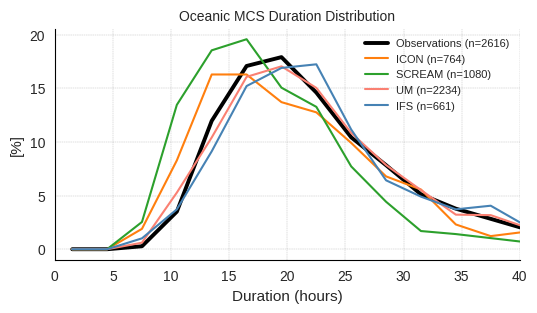

In [64]:
## Full filter
lf = 0.1; lf_var = 'total_landfrac'
fig = plt.figure(figsize=(6, 3))
# ====== 1. Duration Distribution (2-hour bins) ======
ax1 = plt.subplot(1, 1, 1)
duration_bins = np.arange(0, 50, 3)  # 2-hour bins up to 50 hours
mid_bins = 0.5*(duration_bins[1:]+duration_bins[:-1])
for df, label, lw in [(df_trop_obs[(df_trop_obs.start_time>'2020-02-01')&(df_trop_obs.start_time<'2021-01-01')&(df_trop_obs[lf_var] < lf)], 'Observations', 2.8),
                  (df_trop_icon[(df_trop_icon.start_time>'2020-02-01')&(df_trop_icon.start_time<'2021-01-01')&(df_trop_icon[lf_var] < lf)], 'ICON', 1.5),
                  (df_trop_scream[(df_trop_scream.start_time>'2020-02-01')&(df_trop_scream.start_time<'2021-01-01')&(df_trop_scream[lf_var] < lf)], 'SCREAM', 1.5),
                 (df_trop_um[(df_trop_um.start_time>'2020-02-01')&(df_trop_um.start_time<'2021-01-01')&(df_trop_um[lf_var] < lf)],'UM', 1.5),
                  (df_trop_ifs[(df_trop_ifs.start_time>'2020-02-01')&(df_trop_ifs.start_time<'2021-01-01')&(df_trop_ifs[lf_var] < lf)],'IFS', 1.5)]:

    data_hist, bins = np.histogram(df['duration_hours'], bins=duration_bins, range=duration_bins, density=False)
    perc_hist= [i/sum(data_hist)*100 for i in data_hist]

    ax1.plot(mid_bins,perc_hist, label=f'{label} (n={len(df)})', color=colors[label],lw=lw)

ax1.set_facecolor('white')
ax1.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
plt.xlabel('Duration (hours)')
plt.ylabel('[%]')
plt.title('Oceanic MCS Duration Distribution',fontsize=10)
plt.legend(fontsize=8); plt.xlim(0, 40)
ax1.spines['left'].set_color('k'); ax1.spines['bottom'].set_color('k')
ax1.spines['left'].set_linewidth(.8); ax1.spines['bottom'].set_linewidth(.8)

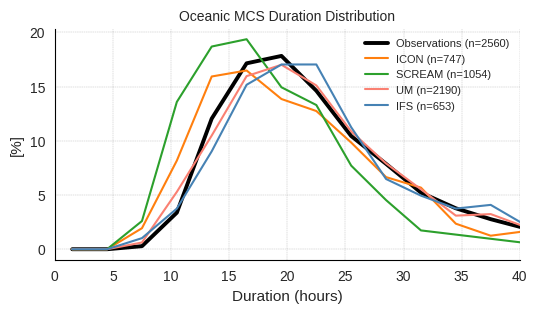

In [65]:
## Full filter
lf = 0.05

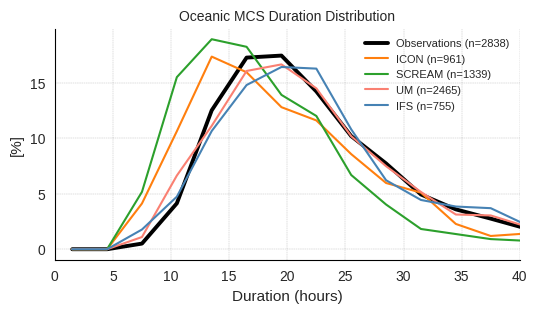

In [66]:
lf = 0.1; lf_var = 'total_landfrac'
#two firsts

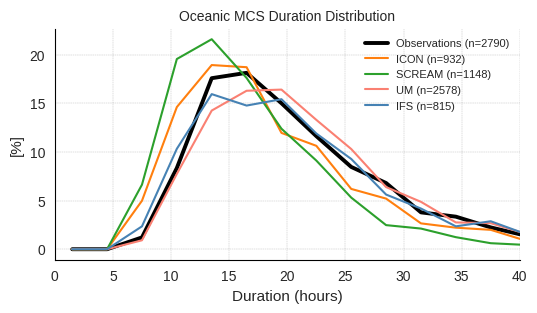

In [67]:
lf = 0.1; lf_var = 'total_landfrac'
##only first 

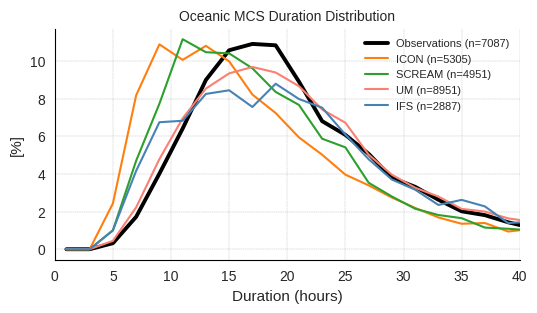

In [19]:

# plt.savefig('plots/mcs_duration_distribution_common.png', dpi=300, bbox_inches='tight')

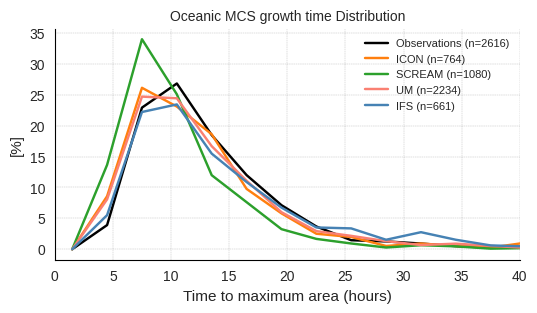

In [69]:
## with splitting
fig = plt.figure(figsize=(6, 3))
# ====== 1. time-to-max-area Distribution (2-hour bins) ======
ax1 = plt.subplot(1, 1, 1)
duration_bins = np.arange(0, 50, 3)  # 2-hour bins up to 50 hours
mid_bins = 0.5*(duration_bins[1:]+duration_bins[:-1])
for df, label in [(df_trop_obs[(df_trop_obs.start_time>'2020-02-01')&(df_trop_obs.start_time<'2021-01-01')&(df_trop_obs[lf_var] < lf)], 'Observations'),
                  (df_trop_icon[(df_trop_icon.start_time>'2020-02-01')&(df_trop_icon.start_time<'2021-01-01')&(df_trop_icon[lf_var] < lf)], 'ICON'),
                  (df_trop_scream[(df_trop_scream.start_time>'2020-02-01')&(df_trop_scream.start_time<'2021-01-01')&(df_trop_scream[lf_var] < lf)], 'SCREAM'),
                 (df_trop_um[(df_trop_um.start_time>'2020-02-01')&(df_trop_um.start_time<'2021-01-01')&(df_trop_um[lf_var] < lf)],'UM'),
                  (df_trop_ifs[(df_trop_ifs.start_time>'2020-02-01')&(df_trop_ifs.start_time<'2021-01-01')&(df_trop_ifs[lf_var] < lf)],'IFS')]:

    data_hist, bins = np.histogram(df['time_to_max_area'], bins=duration_bins, range=duration_bins, density=False)
    perc_hist= [i/sum(data_hist)*100 for i in data_hist]

    ax1.plot(mid_bins,perc_hist, label=f'{label} (n={len(df)})', color=colors[label])

ax1.set_facecolor('white')
ax1.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
plt.xlabel('Time to maximum area (hours)')
plt.ylabel('[%]')
plt.title('Oceanic MCS growth time Distribution',fontsize=10)
plt.legend(fontsize=8); plt.xlim(0, 40)
ax1.spines['left'].set_color('k'); ax1.spines['bottom'].set_color('k')
ax1.spines['left'].set_linewidth(.8); ax1.spines['bottom'].set_linewidth(.8)

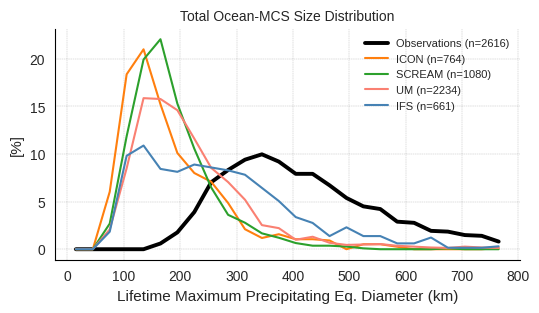

In [72]:
fig = plt.figure(figsize=(6, 3))
# ====== 1. Duration Distribution (2-hour bins) ======
ax1 = plt.subplot(1, 1, 1)
total_area_bins = np.arange(0, 800, 30)  # 25 Larger bins for total area
mid_bins = 0.5*(total_area_bins[1:]+total_area_bins[:-1])
for df, label, lw in [(df_trop_obs[(df_trop_obs.start_time>'2020-02-01')&(df_trop_obs.start_time<'2021-01-01')&(df_trop_obs[lf_var] < lf)], 'Observations', 2.8),
                  (df_trop_icon[(df_trop_icon.start_time>'2020-02-01')&(df_trop_icon.start_time<'2021-01-01')&(df_trop_icon[lf_var] < lf)], 'ICON', 1.5),
                  (df_trop_scream[(df_trop_scream.start_time>'2020-02-01')&(df_trop_scream.start_time<'2021-01-01')&(df_trop_scream[lf_var] < lf)], 'SCREAM', 1.5),
                 (df_trop_um[(df_trop_um.start_time>'2020-02-01')&(df_trop_um.start_time<'2021-01-01')&(df_trop_um[lf_var] < lf)],'UM', 1.5),
                  (df_trop_ifs[(df_trop_ifs.start_time>'2020-02-01')&(df_trop_ifs.start_time<'2021-01-01')&(df_trop_ifs[lf_var] < lf)],'IFS', 1.5)]:
  
    valid_areas = 2*np.sqrt(df['lifetime_maxmax_pf_area'][df['lifetime_maxmax_pf_area'] > 0])
    data_hist, bins = np.histogram(valid_areas, bins=total_area_bins, range=total_area_bins, density=False)
    perc_hist= [i/sum(data_hist)*100 for i in data_hist]

    ax1.plot(mid_bins,perc_hist, label=f'{label} (n={len(df)})', color=colors[label], lw=lw)

ax1.set_facecolor('white')
ax1.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
plt.xlabel('Lifetime Maximum Precipitating Eq. Diameter (km)')
plt.ylabel('[%]')
plt.title('Total Ocean-MCS Size Distribution',fontsize=10)
plt.legend(fontsize=8); #plt.yscale('log'); # plt.xlim(1, 1e6); plt.ylim(1e-1, 30)
ax1.spines['left'].set_color('k'); ax1.spines['bottom'].set_color('k')
ax1.spines['left'].set_linewidth(.8); ax1.spines['bottom'].set_linewidth(.8)

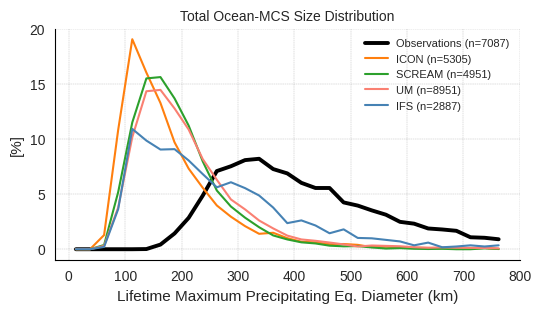

In [18]:


# plt.savefig('plots/mcs_eq_diameter_distribution_common.png', dpi=300, bbox_inches='tight')

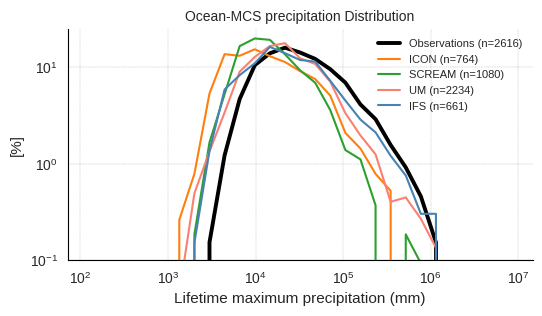

In [88]:
fig = plt.figure(figsize=(6, 3))
# ====== 1. Duration Distribution (2-hour bins) ======
ax1 = plt.subplot(1, 1, 1)
total_rain = np.logspace(np.log10(100), np.log10(1e7), num=30)
mid_bins = 0.5*(total_rain[1:]+total_rain[:-1])
for df, label, lw in [(df_trop_obs[(df_trop_obs.start_time>'2020-02-01')&(df_trop_obs.start_time<'2021-01-01')&(
    df_trop_obs['duration_hours'] > 0)  &(df_trop_obs[lf_var] < lf)], 'Observations', 2.8),
                  (df_trop_icon[(df_trop_icon.start_time>'2020-02-01')&(df_trop_icon.start_time<'2021-01-01')&(
                      df_trop_icon['duration_hours'] > 0)  &(df_trop_icon[lf_var] < lf)], 'ICON', 1.5),
                  (df_trop_scream[(df_trop_scream.start_time>'2020-02-01')&(df_trop_scream.start_time<'2021-01-01')&(
                      df_trop_scream['duration_hours'] > 0)  &(df_trop_scream[lf_var] < lf)], 'SCREAM', 1.5),
                 (df_trop_um[(df_trop_um.start_time>'2020-02-01')&(df_trop_um.start_time<'2021-01-01')&(
                     df_trop_um['duration_hours'] > 0)  &(df_trop_um[lf_var] < lf)],'UM', 1.5),
                  (df_trop_ifs[(df_trop_ifs.start_time>'2020-02-01')&(df_trop_ifs.start_time<'2021-01-01')&(
                      df_trop_ifs['duration_hours'] > 0)  &(df_trop_ifs[lf_var] < lf)],'IFS', 1.5)]:
  
    valid = df['total_total_rain'][df['total_total_rain'] > 0]
    data_hist, bins = np.histogram(valid, bins=total_rain, range=total_rain, density=False)
    perc_hist= [i/sum(data_hist)*100 for i in data_hist]

    ax1.plot(mid_bins,perc_hist, label=f'{label} (n={len(df)})', color=colors[label], lw=lw)

ax1.set_facecolor('white')
ax1.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
plt.xlabel('Lifetime maximum precipitation (mm)')
plt.ylabel('[%]')
plt.title('Ocean-MCS precipitation Distribution',fontsize=10)
plt.legend(fontsize=8); plt.yscale('log'); plt.xscale('log'); plt.ylim(1e-1, 25)
ax1.spines['left'].set_color('k'); ax1.spines['bottom'].set_color('k')
ax1.spines['left'].set_linewidth(.8); ax1.spines['bottom'].set_linewidth(.8)

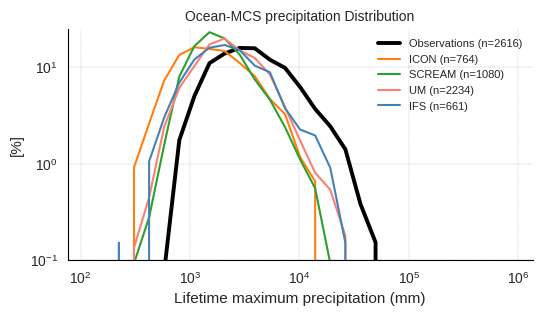

In [73]:
fig = plt.figure(figsize=(6, 3))
# ====== 1. Duration Distribution (2-hour bins) ======
ax1 = plt.subplot(1, 1, 1)
total_rain = np.logspace(np.log10(100), np.log10(1e6), num=30)
mid_bins = 0.5*(total_rain[1:]+total_rain[:-1])
for df, label, lw in [(df_trop_obs[(df_trop_obs.start_time>'2020-02-01')&(df_trop_obs.start_time<'2021-01-01')&(
    df_trop_obs['duration_hours'] > 0)  &(df_trop_obs[lf_var] < lf)], 'Observations', 2.8),
                  (df_trop_icon[(df_trop_icon.start_time>'2020-02-01')&(df_trop_icon.start_time<'2021-01-01')&(
                      df_trop_icon['duration_hours'] > 0)  &(df_trop_icon[lf_var] < lf)], 'ICON', 1.5),
                  (df_trop_scream[(df_trop_scream.start_time>'2020-02-01')&(df_trop_scream.start_time<'2021-01-01')&(
                      df_trop_scream['duration_hours'] > 0)  &(df_trop_scream[lf_var] < lf)], 'SCREAM', 1.5),
                 (df_trop_um[(df_trop_um.start_time>'2020-02-01')&(df_trop_um.start_time<'2021-01-01')&(
                     df_trop_um['duration_hours'] > 0)  &(df_trop_um[lf_var] < lf)],'UM', 1.5),
                  (df_trop_ifs[(df_trop_ifs.start_time>'2020-02-01')&(df_trop_ifs.start_time<'2021-01-01')&(
                      df_trop_ifs['duration_hours'] > 0)  &(df_trop_ifs[lf_var] < lf)],'IFS', 1.5)]:
  
    valid = df['max_total_rain'][df['max_total_rain'] > 0]
    data_hist, bins = np.histogram(valid, bins=total_rain, range=total_rain, density=False)
    perc_hist= [i/sum(data_hist)*100 for i in data_hist]

    ax1.plot(mid_bins,perc_hist, label=f'{label} (n={len(df)})', color=colors[label], lw=lw)

ax1.set_facecolor('white')
ax1.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
plt.xlabel('Lifetime maximum precipitation (mm)')
plt.ylabel('[%]')
plt.title('Ocean-MCS precipitation Distribution',fontsize=10)
plt.legend(fontsize=8); plt.yscale('log'); plt.xscale('log'); plt.ylim(1e-1, 25)
ax1.spines['left'].set_color('k'); ax1.spines['bottom'].set_color('k')
ax1.spines['left'].set_linewidth(.8); ax1.spines['bottom'].set_linewidth(.8)

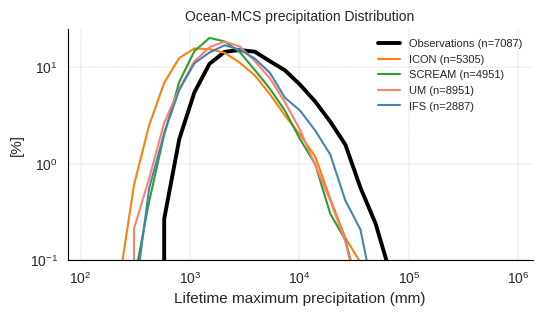

In [20]:


plt.savefig('plots/mcs_totrain_distribution_common.png', dpi=300, bbox_inches='tight')

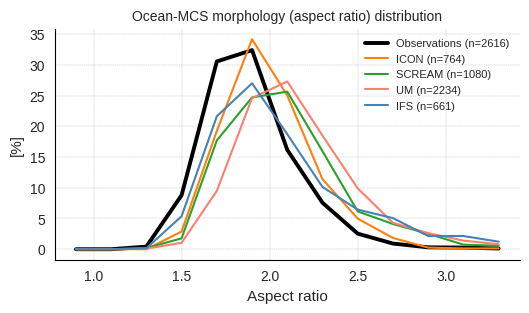

In [75]:
fig = plt.figure(figsize=(6, 3))
# ====== 1. Duration Distribution (2-hour bins) ======
ax1 = plt.subplot(1, 1, 1)
aspect_ratio = np.arange(0.8,3.5,.2)
mid_bins = 0.5*(aspect_ratio[1:]+aspect_ratio[:-1])
for df, label, lw in [(df_trop_obs[(df_trop_obs.start_time>'2020-02-01')&(df_trop_obs.start_time<'2021-01-01')&(
    df_trop_obs['duration_hours'] > 5)  &(df_trop_obs[lf_var] < lf)], 'Observations', 2.8),
                  (df_trop_icon[(df_trop_icon.start_time>'2020-02-01')&(df_trop_icon.start_time<'2021-01-01')&(
                      df_trop_icon['duration_hours'] > 5)  &(df_trop_icon[lf_var] < lf)], 'ICON', 1.5),
                  (df_trop_scream[(df_trop_scream.start_time>'2020-02-01')&(df_trop_scream.start_time<'2021-01-01')&(
                      df_trop_scream['duration_hours'] > 5)  &(df_trop_scream[lf_var] < lf)], 'SCREAM', 1.5),
                 (df_trop_um[(df_trop_um.start_time>'2020-02-01')&(df_trop_um.start_time<'2021-01-01')&(
                     df_trop_um['duration_hours'] > 5)  &(df_trop_um[lf_var] < lf)],'UM', 1.5),
                  (df_trop_ifs[(df_trop_ifs.start_time>'2020-02-01')&(df_trop_ifs.start_time<'2021-01-01')&(
                      df_trop_ifs['duration_hours'] > 5)  &(df_trop_ifs[lf_var] < lf)],'IFS', 1.5)]:
  
    data_hist, bins = np.histogram(df['median_aspectratio'], bins=aspect_ratio, range=aspect_ratio, density=False)
    perc_hist= [i/sum(data_hist)*100 for i in data_hist]

    ax1.plot(mid_bins,perc_hist, label=f'{label} (n={len(df)})', color=colors[label], lw=lw)

ax1.set_facecolor('white')
ax1.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
plt.xlabel('Aspect ratio')
plt.ylabel('[%]')
plt.title('Ocean-MCS morphology (aspect ratio) distribution',fontsize=10)
plt.legend(fontsize=8); #plt.xlim(1e2, 2e5)
ax1.spines['left'].set_color('k'); ax1.spines['bottom'].set_color('k')
ax1.spines['left'].set_linewidth(.8); ax1.spines['bottom'].set_linewidth(.8)

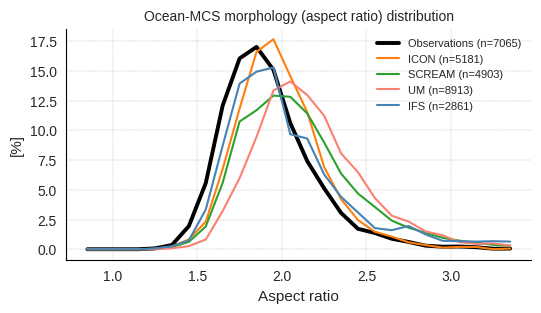

In [21]:


plt.savefig('plots/mcs_aspectratio_distribution_common.png', dpi=300, bbox_inches='tight')

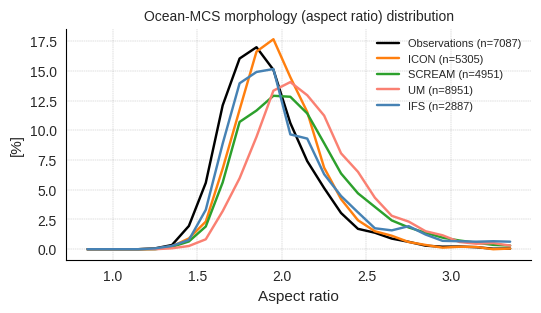

In [48]:
# no duration filtering

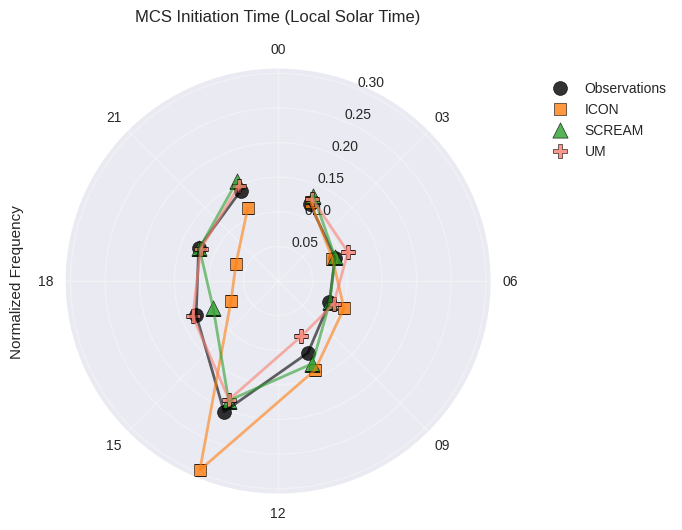

In [76]:
fig = plt.figure(figsize=(7, 7))
# ====== Polar scatter plot for Solar Time ======
ax9 = plt.subplot(1, 1, 1, projection='polar')

# Create polar histogram
theta_bins = np.linspace(0, 2*np.pi, 9)  # 8 bins for 3-hour intervals
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

# Define markers for each source
markers = {'Observations': 'o', 'ICON': 's', 'SCREAM': '^', 'UM': 'P'}
marker_sizes = {'Observations': 100, 'ICON': 80, 'SCREAM': 120, 'UM': 100}

for df, label in [(df_trop_obs, 'Observations'), (df_trop_icon, 'ICON'), (df_trop_scream, 'SCREAM'), (df_trop_um, 'UM')]:
    # Convert hours to radians (0 hours = top, clockwise)
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    
    # Create histogram
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)  # Normalize by total count
    
    # Plot as scatter points
    ax9.scatter(theta_centers, counts_normalized, 
               s=marker_sizes[label], alpha=0.8,
               label=label, color=colors[label], 
               marker=markers[label], 
               edgecolors='black', linewidth=0.5)

# Connect points with lines for better visualization
for df, label in [(df_trop_obs, 'Observations'), (df_trop_icon, 'ICON'), (df_trop_scream, 'SCREAM'), (df_trop_um, 'UM')]:
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)
    
    # Add connecting lines
    ax9.plot(theta_centers, counts_normalized, 
             color=colors[label], alpha=0.6, linewidth=2)

# Set labels for 24-hour clock
ax9.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax9.set_xticklabels(['00', '03', '06', '09', '12', '15', '18', '21'])
ax9.set_theta_zero_location('N')
ax9.set_theta_direction(-1)
ax9.set_title('MCS Initiation Time (Local Solar Time)', pad=15, fontsize=12)

# Customize the radial axis
ax9.set_ylim(0, None)
ax9.set_ylabel('Normalized Frequency', labelpad=30)

# Add legend with custom positioning
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.0), fontsize=10)

# Add grid
ax9.grid(True, alpha=0.3)

plt.tight_layout()

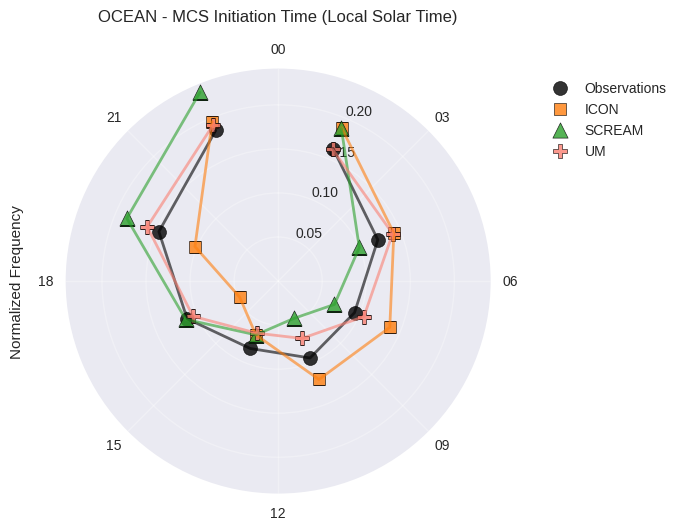

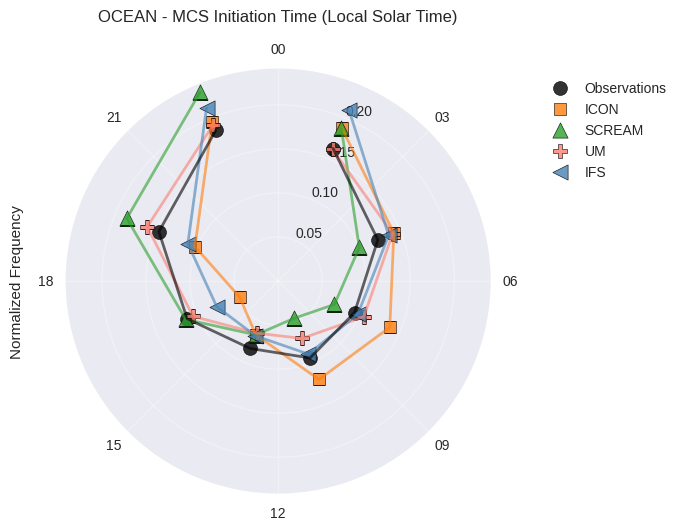

In [80]:
fig = plt.figure(figsize=(7, 7)) ###ONLY FREQUENCY
# ====== Polar scatter plot for Solar Time ======
ax9 = plt.subplot(1, 1, 1, projection='polar')

# Create polar histogram
theta_bins = np.linspace(0, 2*np.pi, 9)  # 8 bins for 3-hour intervals
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

# Define markers for each source
markers = {'Observations': 'o', 'ICON': 's', 'SCREAM': '^', 'UM': 'P','IFS': '<'}
marker_sizes = {'Observations': 100, 'ICON': 80, 'SCREAM': 120, 'UM': 100, 'IFS': 120}

for df, label in [(df_trop_obs[df_trop_obs[lf_var] <0.1],
                   'Observations'), 
                  (df_trop_icon[df_trop_icon[lf_var] <0.1], 'ICON'), 
                  (df_trop_scream[df_trop_scream[lf_var] <0.1], 'SCREAM'),
                 (df_trop_um[df_trop_um[lf_var] <0.1], 'UM'),(df_trop_ifs[df_trop_ifs[lf_var] <0.1], 'IFS')]:
    # Convert hours to radians (0 hours = top, clockwise)
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    
    # Create histogram
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)  # Normalize by total count
    
    # Plot as scatter points
    ax9.scatter(theta_centers, counts_normalized, 
               s=marker_sizes[label], alpha=0.8,
               label=label, color=colors[label], 
               marker=markers[label], 
               edgecolors='black', linewidth=0.5)

# Connect points with lines for better visualization
for df, label in [
                  (df_trop_icon[df_trop_icon[lf_var] <0.1], 'ICON'), 
                  (df_trop_scream[df_trop_scream[lf_var] <0.1], 'SCREAM'),
                 (df_trop_um[df_trop_um[lf_var] <0.1], 'UM'),
                 (df_trop_ifs[df_trop_ifs[lf_var] <0.1], 'IFS'),
(df_trop_obs[df_trop_obs[lf_var] <0.1], 'Observations'), ]:
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)
    
    # Add connecting lines
    ax9.plot(theta_centers, counts_normalized, 
             color=colors[label], alpha=0.6, linewidth=2)

# Set labels for 24-hour clock
ax9.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax9.set_xticklabels(['00', '03', '06', '09', '12', '15', '18', '21'])
ax9.set_theta_zero_location('N')
ax9.set_theta_direction(-1)
ax9.set_title('OCEAN - MCS Initiation Time (Local Solar Time)', pad=15, fontsize=12)

# Customize the radial axis
ax9.set_ylim(0, None)
ax9.set_ylabel('Normalized Frequency', labelpad=30)

# Add legend with custom positioning
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.0), fontsize=10)

# Add grid
ax9.grid(True, alpha=0.3)

plt.tight_layout()

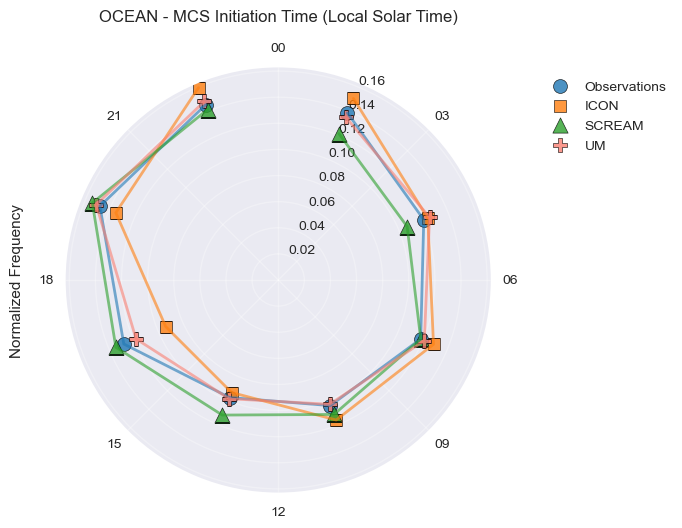

In [18]:
#old

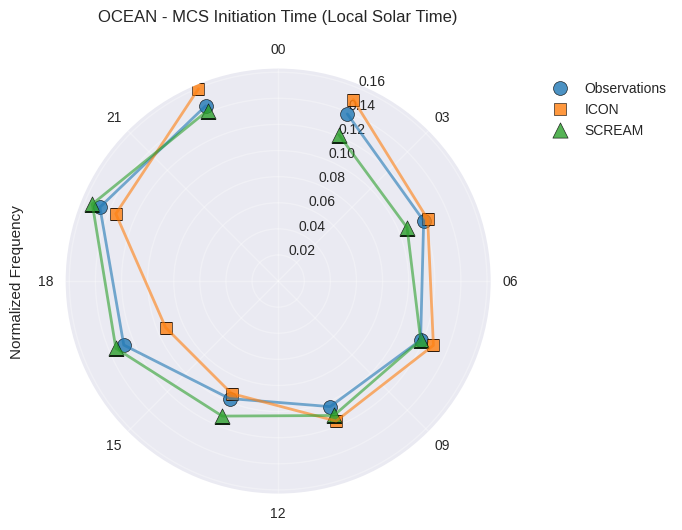

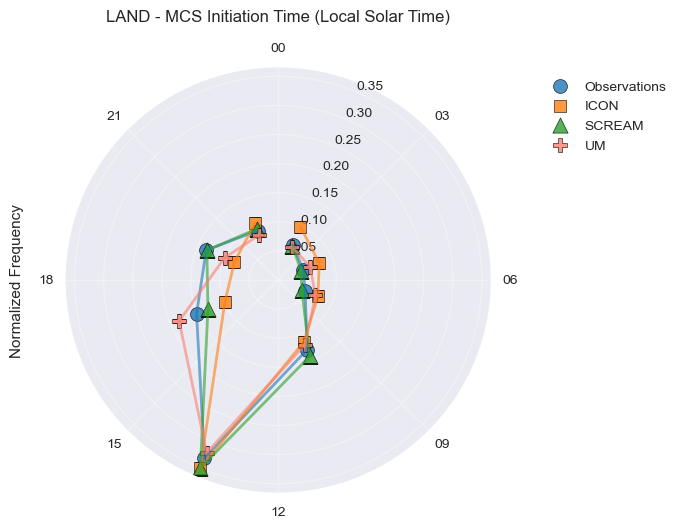

In [19]:
fig = plt.figure(figsize=(7, 7))
# ====== Polar scatter plot for Solar Time ======
ax9 = plt.subplot(1, 1, 1, projection='polar')

# Create polar histogram
theta_bins = np.linspace(0, 2*np.pi, 9)  # 8 bins for 3-hour intervals
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

# Define markers for each source
markers = {'Observations': 'o', 'ICON': 's', 'SCREAM': '^', 'UM': 'P'}
marker_sizes = {'Observations': 100, 'ICON': 80, 'SCREAM': 120, 'UM': 100}

for df, label in [(df_trop_obs[df_trop_obs[lf_var] >0.9],
                   'Observations'), 
                  (df_trop_icon[df_trop_icon[lf_var] >0.9], 'ICON'), 
                  (df_trop_scream[df_trop_scream[lf_var] >0.9], 'SCREAM'),
                 (df_trop_um[df_trop_um[lf_var] >0.9], 'UM')]:
    # Convert hours to radians (0 hours = top, clockwise)
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    
    # Create histogram
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)  # Normalize by total count
    
    # Plot as scatter points
    ax9.scatter(theta_centers, counts_normalized, 
               s=marker_sizes[label], alpha=0.8,
               label=label, color=colors[label], 
               marker=markers[label], 
               edgecolors='black', linewidth=0.5)

# Connect points with lines for better visualization
for df, label in [(df_trop_obs[df_trop_obs[lf_var] >0.9], 'Observations'), 
                  (df_trop_icon[df_trop_icon[lf_var] >0.9], 'ICON'), 
                  (df_trop_scream[df_trop_scream[lf_var] >0.9], 'SCREAM'),
                 (df_trop_um[df_trop_um[lf_var] >0.9], 'UM')]:
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)
    
    # Add connecting lines
    ax9.plot(theta_centers, counts_normalized, 
             color=colors[label], alpha=0.6, linewidth=2)

# Set labels for 24-hour clock
ax9.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax9.set_xticklabels(['00', '03', '06', '09', '12', '15', '18', '21'])
ax9.set_theta_zero_location('N')
ax9.set_theta_direction(-1)
ax9.set_title('LAND - MCS Initiation Time (Local Solar Time)', pad=15, fontsize=12)

# Customize the radial axis
ax9.set_ylim(0, None)
ax9.set_ylabel('Normalized Frequency', labelpad=30)

# Add legend with custom positioning
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.0), fontsize=10)

# Add grid
ax9.grid(True, alpha=0.3)

plt.tight_layout()


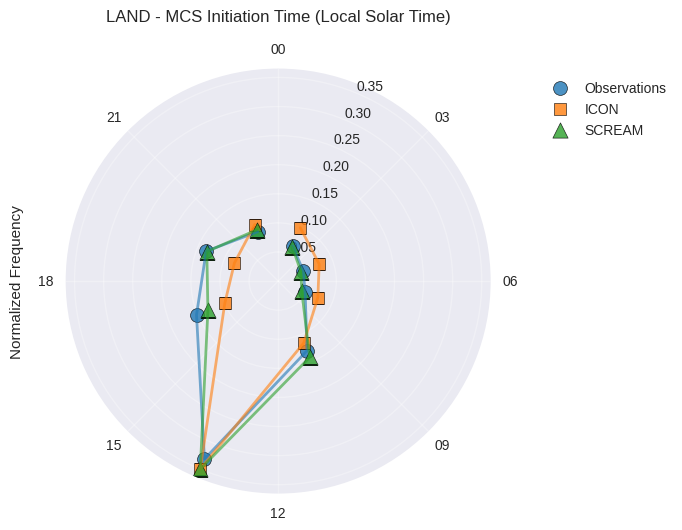

In [47]:
df_trop_obs.columns

Index(['track_id', 'duration_hours', 'initial_lat', 'initial_lon', 'mean_area',
       'median_area', 'total_area', 'start_time', 'local_solar_hour',
       'source'],
      dtype='object')

In [51]:
df_trop_obs['duration_hours'].quantile(.5)

np.float64(17.0)

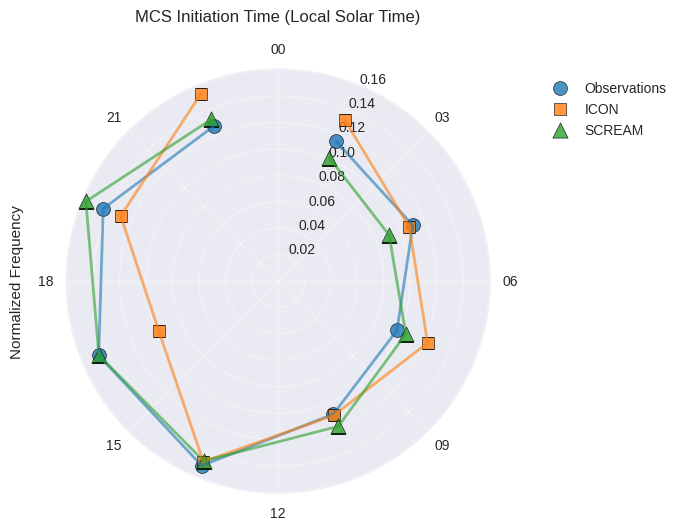

In [55]:
fig = plt.figure(figsize=(7, 7)); pc = 0.9
# ====== Polar scatter plot for Solar Time ======
ax9 = plt.subplot(1, 1, 1, projection='polar')

# Create polar histogram
theta_bins = np.linspace(0, 2*np.pi, 9)  # 8 bins for 3-hour intervals
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

# Define markers for each source
markers = {'Observations': 'o', 'ICON': 's', 'SCREAM': '^'}
marker_sizes = {'Observations': 100, 'ICON': 80, 'SCREAM': 120}

for df, label in [(df_trop_obs[df_trop_obs.duration_hours>df_trop_obs['duration_hours'].quantile(pc)],
                   'Observations'), 
                  (df_trop_icon[df_trop_icon.duration_hours>df_trop_icon['duration_hours'].quantile(pc)], 'ICON'), 
                  (df_trop_scream[df_trop_scream.duration_hours>df_trop_scream['duration_hours'].quantile(pc)], 'SCREAM')]:
    # Convert hours to radians (0 hours = top, clockwise)
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    
    # Create histogram
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)  # Normalize by total count
    
    # Plot as scatter points
    ax9.scatter(theta_centers, counts_normalized, 
               s=marker_sizes[label], alpha=0.8,
               label=label, color=colors[label], 
               marker=markers[label], 
               edgecolors='black', linewidth=0.5)

# Connect points with lines for better visualization
for df, label in [(df_trop_obs[df_trop_obs.duration_hours>df_trop_obs['duration_hours'].quantile(pc)], 
                   'Observations'), 
                  (df_trop_icon[df_trop_icon.duration_hours>df_trop_icon['duration_hours'].quantile(pc)], 'ICON'), 
                  (df_trop_scream[df_trop_scream.duration_hours>df_trop_scream['duration_hours'].quantile(pc)],
                   'SCREAM')]:
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)
    
    # Add connecting lines
    ax9.plot(theta_centers, counts_normalized, 
             color=colors[label], alpha=0.6, linewidth=2)

# Set labels for 24-hour clock
ax9.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax9.set_xticklabels(['00', '03', '06', '09', '12', '15', '18', '21'])
ax9.set_theta_zero_location('N')
ax9.set_theta_direction(-1)
ax9.set_title('MCS Initiation Time (Local Solar Time)', pad=15, fontsize=12)

# Customize the radial axis
ax9.set_ylim(0, None)
ax9.set_ylabel('Normalized Frequency', labelpad=30)

# Add legend with custom positioning
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.0), fontsize=10)

# Add grid
ax9.grid(True, alpha=0.3)

plt.tight_layout()